# GourmetAI – Production‑Grade Food Image Classification

This notebook implements a **complete AI engineering workflow** for food image classification.<br>

GourmetAI Inc., a renowned company in the food technology sector, faces growing challenges in improving the accuracy and efficiency of food image classification systems. The need to provide customers with advanced, high-quality solutions for accurately identifying and categorizing foods is essential for enhancing the user experience and optimizing business processes.<br>
Project Benefits<br>
The implementation of advanced deep learning techniques for food image classification offers numerous advantages:<br>
Improved User Experience: An accurate and reliable system significantly enhances the user experience in food image recognition applications by providing fast and accurate results.<br>
Optimization of Business Processes: Automating image classification reduces the time and resources required to identify and categorize foods, improving overall operational efficiency.<br>
Technological Innovation: Utilizing advanced deep learning techniques fosters innovation within the company, enabling it to tackle complex challenges in the field of image recognition.<br>
Business Objectives: Improving the performance of classification models helps GourmetAI Inc. meet its business objectives, solidifying its position as a leader in the food technology sector.<br>

Project Details<br>
GourmetAI Inc. has requested the development of an advanced food image classification model using deep learning techniques. The project will be based on the Food Classification dataset, enriched with data augmentation techniques to improve the diversity and quality of the available data.<br>
Project Objectives<br>
Augmentation Strategies: Implement various augmentation techniques to enrich the dataset, improving data variability and quality.<br>
Dataset Division: Split the dataset into a training set, validation set, and test set to ensure proper model training and validation.<br>
Network Architectures and Transfer Learning: Select and implement one or more neural network architectures suitable for the problem, using transfer learning to leverage pre-trained models.<br>
Fine-Tuning and Hyperparameter Selection: Create a custom classifier, select hyperparameters, and optimize the model through training and validation processes.<br>
Validation and Regularization: Use validation techniques to improve hyperparameter selection and address potential issues with regularization techniques.<br>
Final Testing: Perform a final test to verify the model’s generalization capabilities and achieve the desired performance.<br>




Pipeline components:

1. Environment setup
2. Dataset download
3. Exploratory Data Analysis (EDA)
4. Data augmentation
5. Train / Validation / Test split
6. Data Pipeline: PyTorch DataLoaders
7. Transfer Learning Model
8. Optuna Hyperparameter Tuning
9. Phase 1 — Train Classifier Head (Frozen Backbone)
10. Phase 2 — Progressive Fine-Tuning (Unfreeze Last 3 Blocks)
11. Model Evaluation
12. Inference demo


## 1. Environment Setup

In [ ]:
%pip install torch torchvision optuna scikit-learn matplotlib seaborn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import copy
import zipfile
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Dataset Download

In [ ]:
dataset_url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip"
dataset_zip = "dataset_food_classification.zip"
dataset_dir = "food_dataset"

if not os.path.exists(dataset_zip):
    print("Downloading dataset...")
    r = requests.get(dataset_url, stream=True)
    with open(dataset_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

if not os.path.exists(dataset_dir):
    print("Extracting...")
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)

print("Dataset ready")

Extracting...
Dataset ready


## 3. Exploratory Data Analysis (EDA)

We define the directory paths for the training, validation, and test sets. After cleaning the folders by removing metadata artifacts (like __MACOSX), we load the training data to perform an initial Exploratory Data Analysis (EDA). This allows us to inspect the class distribution and ensure the dataset is balanced.

Total images: 8960
Classes (14): ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'cheesecake', 'chicken_curry', 'ice_cream', 'omelette', 'sushi']
Min/Max per class: 640 / 640


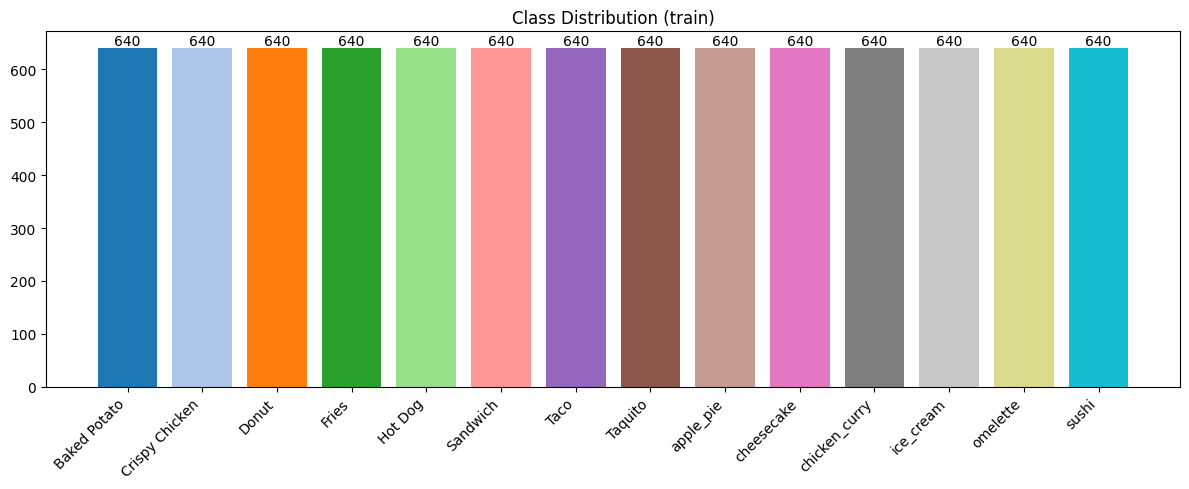

In [ ]:
# Paths
base_dir    = "/content/food_dataset/dataset"
train_dir   = os.path.join(base_dir, "train")
val_dir     = os.path.join(base_dir, "val")
test_dir    = os.path.join(base_dir, "test")

# Remove __MACOSX if exist (in all splits)
for split_dir in [base_dir, train_dir, val_dir, test_dir]:
    macosx_path = os.path.join(split_dir, '__MACOSX')
    if os.path.exists(macosx_path):
        shutil.rmtree(macosx_path)
        print(f"Dir __MACOSX removed from {split_dir}")

# Load without transform for EDA (using train split)
dataset_preview = datasets.ImageFolder(train_dir)
classes = dataset_preview.classes
num_classes = len(classes)

labels = [label for _, label in dataset_preview]
class_counts = Counter(labels)
counts = [class_counts[i] for i in range(num_classes)]

print(f"Total images: {len(dataset_preview)}")
print(f"Classes ({num_classes}): {classes}")
print(f"Min/Max per class: {min(counts)} / {max(counts)}")

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, counts, color=[plt.cm.tab20(i / num_classes) for i in range(num_classes)])
plt.bar_label(bars)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (train)")
plt.tight_layout()
plt.show()

EDA Insights: Class Distribution
The exploratory analysis of the training set reveals a perfectly balanced dataset.<br>

Total Samples: 8,960 images.<br>

Number of Classes: 14.<br>

Samples per Class: 640 (Uniform).<br>

This balance is ideal for deep learning as it prevents the model from becoming biased toward more frequent classes. We can proceed with training using standard cross-entropy loss without the need for class weighting or data augmentation specifically aimed at balancing.<br>

### Sample Images

To verify the integrity of the data loading process, we visualize a random sample of images from the training set. This step ensures that the labels correctly correspond to the visual content and provides a first look at the variety and quality of the images within the dataset.

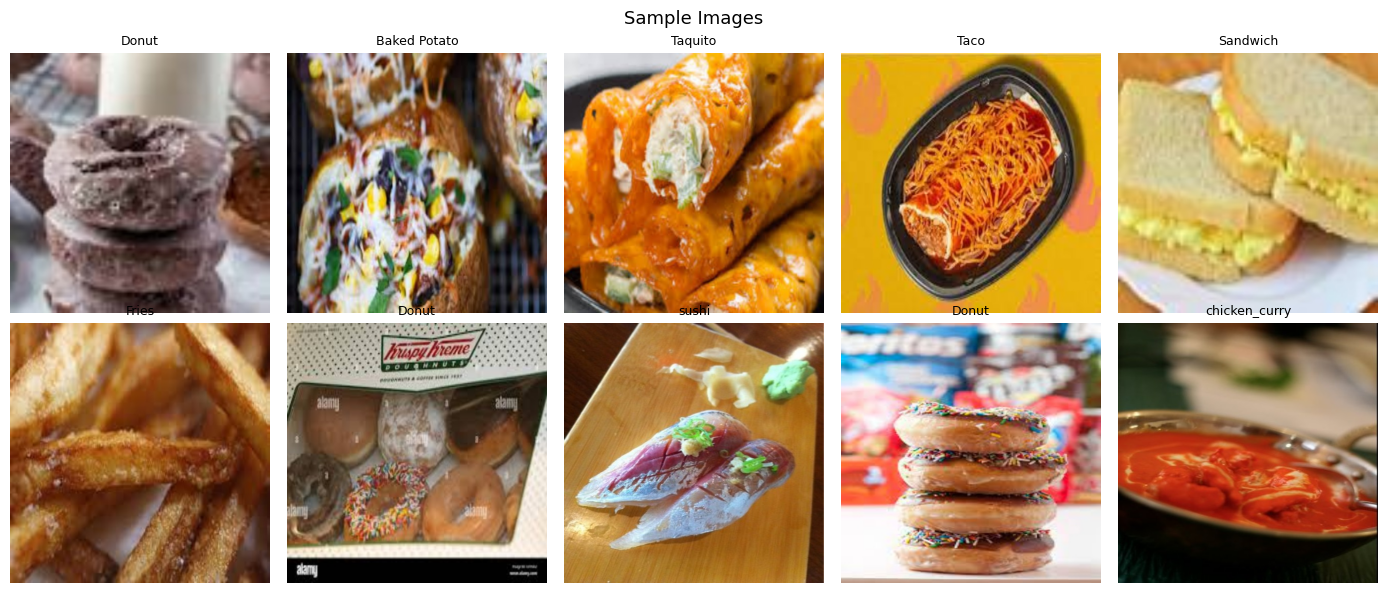

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax in axes.flatten():
    idx = random.randint(0, len(dataset_preview) - 1)
    img, label = dataset_preview[idx]
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

A qualitative review of the sampled images leads to the following observations:<br>

High Inter-class Variance: The visual features of the 14 classes are distinct, which is promising for the model's discriminative power.<br>

Real-world Noise: The presence of brand logos, varying textures, and different plating styles suggests that the model will need to learn robust features to generalize well.<br>

Consistency: All randomly selected samples match their assigned labels, confirming a clean and reliable dataset structure.

## 4. Data augmentation



In this step, we define the preprocessing pipelines for our datasets. A key decision is resizing the images to 224x224 pixels.<br>
Why 224x224? Most state-of-the-art architectures (such as ResNet, VGG, and EfficientNet) were originally trained on the ImageNet dataset using this specific resolution. Using the same dimensions offers several advantages:<br>
- Transfer Learning Compatibility: It allows us to leverage pre-trained weights without modifying the initial layers of the network.<br>
- Computational Efficiency: $224 \times 224$ is a "sweet spot" that preserves enough spatial detail for food recognition while keeping the memory footprint and training time manageable.<br>
- Normalization: It ensures that every input tensor has a consistent shape, which is a requirement for batch processing in PyTorch. We use standard ImageNet statistics (mean and standard deviation) to ensure our input distribution matches the pre-trained weights often used in Transfer Learning.<br>
- Data Augmentation Strategy: For the training set, we apply aggressive augmentation (Random Cropping, Flips, Rotation, and Color Jitter) to manually increase the diversity of our 8,960 images. This forces the model to learn invariant features, making it more robust against changes in orientation or lighting.For validation and testing, we use a deterministic approach: resizing to 256 and then center-cropping to 224 to ensure the evaluation is consistent and focused on the main subject.

In [ ]:
# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### Augmentation Visualization (unnormalized for display)

Before proceeding to training, it is essential to visualize how the augmentation pipeline transforms our images. The goal is to create variations that represent realistic changes in the data without distorting the food items beyond recognition. This helps prevent overfitting<br>

Below, we take a single sample and pass it through the vis_transforms multiple times to observe the effects of:<br>

Random Cropping & Resizing: To make the model scale-invariant.<br>

Horizontal Flips & Rotations: To account for different camera angles.<br>

Color Jittering: To simulate various lighting conditions and white balance settings.<br>

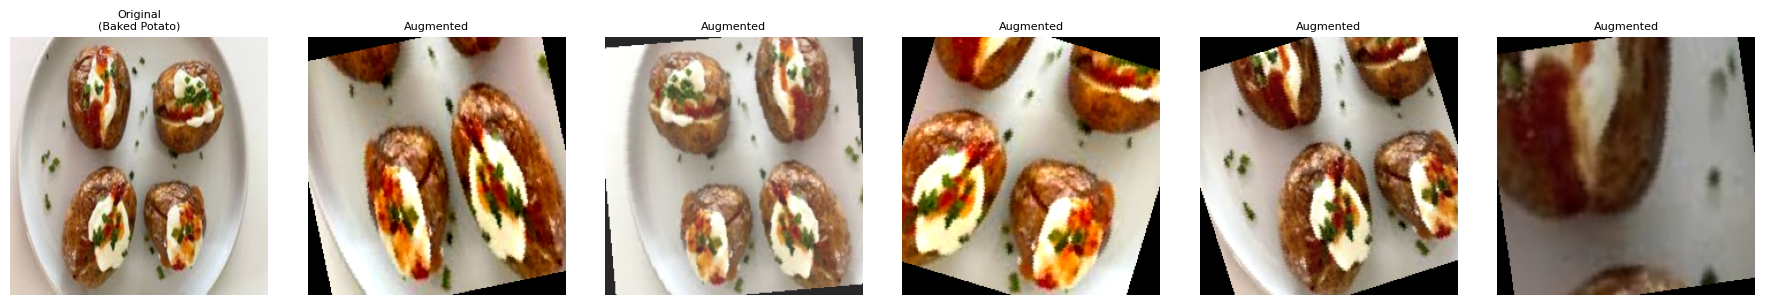

In [ ]:
vis_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])

sample_img, sample_label = dataset_preview[random.randint(0, len(dataset_preview) - 1)]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(sample_img)
axes[0].set_title(f"Original\n({classes[sample_label]})", fontsize=8)
axes[0].axis("off")

for ax in axes[1:]:
    aug_img = vis_transforms(sample_img).permute(1, 2, 0).numpy()
    aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img)
    ax.set_title("Augmented", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

The sample grid shows the pipeline in action on a single 'Baked Potato' image:<br>

- Geometric Robustness: Through 20-degree rotations and random flips, we simulate natural variations in how a user might take a photo.<br>

- Scale Invariance: The cropping mechanism ensures that the model learns to identify the food whether it occupies the whole frame or only a portion of it.<br>

- Color Resilience: The brightness and contrast adjustments prevent the model from over-relying on specific lighting conditions.<br>


Note: The black borders introduced by rotation are a standard side effect; the model will eventually learn to ignore these constant patterns.<br>

Conclusion: The pipeline successfully generates challenging but realistic samples that will help prevent overfitting during the training phase.

## 5. Train / Validation / Test Split

After verifying the raw data and testing our augmentation strategy, we formally define the datasets for the model.<br>

1. Training Data: Augmented to prevent overfitting.<br>

2. Validation Data: Used for hyperparameter tuning during training.<br>

3. Test Data: Held out for the final performance evaluation.<br>

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 8960 | Val: 2240 | Test: 2800


## 6. Data Pipeline: PyTorch DataLoaders

We wrap our datasets into PyTorch DataLoaders to manage batching and shuffling efficiently.<br>

  Batch Size: Set to 32, balancing memory usage and gradient stability.<br>

  Shuffle: Enabled for the training set to ensure the model doesn't learn the order of the images.<br>

  Performance Optimization: We use num_workers=4 for parallel data loading and pin_memory=True to speed up the transfer of tensors from CPU to GPU.<br>

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 7. Transfer Learning Model

We leverage **Transfer Learning** using the **EfficientNet-B0** architecture, which is known for its excellent balance between accuracy and efficiency.<br>

Our Strategy:<br>
- Feature Extraction: We load the model with pre-trained ImageNet weights and freeze the backbone parameters. This allows us to keep the powerful feature extraction capabilities learned from a massive dataset.<br>

- Custom Classifier Head: We replace the original top layer with a new MLP (Multi-Layer Perceptron) designed for our 14 food classes. It includes SiLU activation and Dropout layers to mitigate overfitting.<br>

- Trainable Parameters: By freezing the base, we significantly reduce the number of weights to be updated, leading to faster training and lower risk of forgetting general visual features.<br>

In [ ]:
def build_model(dropout: float = 0.4) -> nn.Module:
    """
    Builds a custom classification model based on the EfficientNet-B0 architecture.

    The function uses transfer learning by loading pre-trained ImageNet weights
    and freezing the backbone layers to retain feature extraction capabilities.
    The original classifier is replaced with a custom head consisting of a
    fully connected layer, SiLU activation (Unlike ReLU, which has a sharp "elbow"
    at zero, SiLU is a smooth, continuously differentiable function. This helps
    the gradient flow more effectively during backpropagation), and dropout layers
    for regularization.

    Args:
        dropout (float): Probability of an element to be zeroed in the first
            dropout layer. The second dropout layer uses half of this value.
            Defaults to 0.4.

    Returns:
        nn.Module: The compiled PyTorch model moved to the target device (CPU/GPU).
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.SiLU(), #Sigmoid Linear Unit
        nn.Dropout(p=dropout / 2),
        nn.Linear(512, num_classes),
    )
    return model.to(device)

model = build_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Trainable params: 663,054 / 4,670,602


## 8. Optuna Hyperparameter Tuning

To maximize the performance of our food classifier, we implement an automated search for the best hyperparameters using Optuna. Instead of manual tuning, we use the Tree-structured Parzen Estimator (TPE) sampler to intelligently explore the search space.<br>

Key Components:<br>
run_one_epoch: A flexible helper function that handles both the training (with backpropagation) and validation logic.<br>

objective function: Defines the search space for learning rate, dropout, weight decay, label smoothing, and learning rate schedulers.<br>

Shortened Trials: Each trial runs for 3 epochs to quickly evaluate the potential of a specific configuration before committing to a full training session.

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    """
    Performs a single epoch of training or evaluation.

    This function is versatile: if an optimizer is provided, it operates in
    training mode (enabling gradients and updating weights). Otherwise, it
    runs in evaluation mode (disabling gradients).

    Args:
        model (nn.Module): The neural network model to use.
        loader (DataLoader): The data loader providing batches (train, val, or test).
        criterion (callable): The loss function (e.g., CrossEntropyLoss).
        optimizer (torch.optim.Optimizer, optional): The optimizer for weight
            updates. If None, the function runs in evaluation mode. Defaults to None.

    Returns:
        tuple: A tuple containing:
            - avg_loss (float): Average loss over the entire epoch.
            - accuracy (float): Classification accuracy (range 0.0 to 1.0).
    """
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


def objective(trial):
    """
    Objective function for Optuna hyperparameter optimization.

    This function defines the search space for various hyperparameters (learning
    rate, dropout, weight decay, label smoothing, and scheduler type). It builds
    a model instance for each trial, performs a shortened training phase,
    and returns the validation loss as the metric to minimize.

    Args:
        trial (optuna.trial.Trial): A specific trial object that provides
            suggested hyperparameter values.

    Returns:
        float: The validation loss achieved by the model with the suggested
            hyperparameters, used by Optuna to guide the search.
    """
    lr      = trial.suggest_float("lr",      1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2,  0.6)
    wd      = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    label_smooth = trial.suggest_float("label_smoothing", 0.0, 0.2)
    scheduler    = trial.suggest_categorical("scheduler", ["cosine", "step", "none"])

    trial_model = build_model(dropout=dropout).to(device)
    optimizer   = optim.AdamW(trial_model.parameters(), lr=lr, weight_decay=wd)
    criterion   = nn.CrossEntropyLoss(label_smoothing=label_smooth)

    if scheduler == "cosine":
      sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
    elif scheduler == "step":
      sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    else:
      sched = None

    # Train few quick epochs to rank hyperparams
    for _ in range(3):
        run_one_epoch(trial_model, train_loader, criterion, optimizer)
        if sched:
          sched.step()

    val_loss, val_acc = run_one_epoch(trial_model, val_loader, criterion)
    return val_loss


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("\nBest params:", study.best_params)
print(f"Best val loss: {study.best_value:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Best params: {'lr': 0.0009805387063904364, 'dropout': 0.44629481654950665, 'weight_decay': 0.008218740277844324, 'label_smoothing': 0.005762206034078213, 'scheduler': 'step'}
Best val loss: 0.8315


## 9. Phase 1 — Train Classifier Head (Frozen Backbone)

Following the Optuna study, we extract the best-performing hyperparameters to configure our final training pipeline. This ensures that we are not just training with arbitrary values, but with a setup tailored specifically for our food dataset.<br>

Phase 1: Training the Classifier Head<br>
We adopt a Two-Phase training strategy:<br>

1. Backbone Freezing: We freeze the pre-trained weights of the EfficientNet-B0 backbone.<br>

2. Head Adaptation: We only train the custom classifier layers. This prevents large gradient updates from destroying the pre-trained knowledge while allowing the model to adapt to our 14 food categories.<br>

The train_model function below includes Early Stopping to prevent overfitting and Learning Rate Scheduling for smoother convergence.

In [ ]:
BEST_LR           = study.best_params["lr"]
BEST_DROPOUT      = study.best_params["dropout"]
BEST_WD           = study.best_params["weight_decay"]
BEST_LABEL_SMOOTH = study.best_params["label_smoothing"]
BEST_SCHEDULER    = study.best_params["scheduler"]

model     = build_model(dropout=BEST_DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=BEST_LABEL_SMOOTH)


def train_model(
    model, train_loader, val_loader, criterion,
    lr, weight_decay, epochs, patience=5, tag="phase",
    scheduler_name="cosine"
):
    """
    Executes the complete training and validation pipeline for the model.

    This function manages the training loop, including optimization, learning rate
    scheduling, and performance tracking. It implements Early Stopping to prevent
    overfitting and ensures that the model returns with the weights that achieved
    the lowest validation loss.

    Args:
        model (nn.Module): The neural network to train.
        train_loader (DataLoader): Loader for the training data.
        val_loader (DataLoader): Loader for the validation data.
        criterion (callable): Loss function (e.g., CrossEntropyLoss).
        lr (float): Initial learning rate for the AdamW optimizer.
        weight_decay (float): L2 regularization coefficient for AdamW.
        epochs (int): Maximum number of training epochs.
        patience (int): Number of epochs to wait for improvement in validation loss
            before triggering Early Stopping. Defaults to 5.
        tag (str): A descriptive string used for print formatting (e.g., "P1").
            Defaults to "phase".
        scheduler_name (str): Type of learning rate scheduler to use
            ('cosine', 'step', or None). Defaults to "cosine".

    Returns:
        dict: A dictionary ('history') containing lists of training/validation
            losses and accuracies for each completed epoch.
    """
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )


    if scheduler_name == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_name == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    else:
        scheduler = None

    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0
    history       = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_one_epoch(model, val_loader, criterion)
        if scheduler:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"[{tag}] Epoch {epoch:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {vl_loss:.4f} acc {vl_acc:.3f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    return history


# freeze backbone: training only the head
print("=== Phase 1: Classifier head only ===")
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

history_p1 = train_model(
    model, train_loader, val_loader, criterion,
    lr=BEST_LR, weight_decay=BEST_WD,
    epochs=15, patience=4, tag="P1",
    scheduler_name=BEST_SCHEDULER
)

=== Phase 1: Classifier head only ===
[P1] Epoch 01/15 | train loss 1.6180 acc 0.485 | val loss 0.9785 acc 0.713
[P1] Epoch 02/15 | train loss 1.3700 acc 0.557 | val loss 0.8768 acc 0.730
[P1] Epoch 03/15 | train loss 1.2878 acc 0.579 | val loss 0.8386 acc 0.742
[P1] Epoch 04/15 | train loss 1.2506 acc 0.598 | val loss 0.8198 acc 0.748
[P1] Epoch 05/15 | train loss 1.2224 acc 0.600 | val loss 0.7866 acc 0.756
[P1] Epoch 06/15 | train loss 1.2050 acc 0.610 | val loss 0.7897 acc 0.754
[P1] Epoch 07/15 | train loss 1.2112 acc 0.613 | val loss 0.7654 acc 0.761
[P1] Epoch 08/15 | train loss 1.1833 acc 0.620 | val loss 0.7592 acc 0.771
[P1] Epoch 09/15 | train loss 1.1897 acc 0.614 | val loss 0.7642 acc 0.762
[P1] Epoch 10/15 | train loss 1.1752 acc 0.618 | val loss 0.7565 acc 0.771
[P1] Epoch 11/15 | train loss 1.1827 acc 0.615 | val loss 0.7527 acc 0.776
[P1] Epoch 12/15 | train loss 1.1903 acc 0.618 | val loss 0.7578 acc 0.774
[P1] Epoch 13/15 | train loss 1.1733 acc 0.625 | val loss 0.76

## 10. Phase 2 — Progressive Fine-Tuning (Unfreeze Last 3 Blocks)

Phase 2: Partial Fine-Tuning<br>
After stabilizing the classifier head, we proceed to Fine-Tuning. Instead of unfreezing the entire network—which could lead to catastrophic forgetting—we strategically unfreeze only the last three MBConv blocks of the EfficientNet-B0 backbone.<br>

Key Adjustments:<br>
- Discriminative Learning Rates: We use a significantly lower learning rate (BEST_LR / 10) for this phase. This prevents large updates from distorting the high-level features already learned by the backbone.

- Refining Features: This allows the model to adjust its deep feature extractors to better recognize the specific textures and shapes of food items in our dataset.

- Parameter Efficiency: We calculate the new number of trainable parameters to monitor the increased model capacity.

In [ ]:
# Unfreeze last 3 MBConv blocks of EfficientNet-B0 backbone
for param in model.features[-3:].parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 trainable params: {trainable:,}")

print("\n=== Phase 2: Fine-tuning last 3 blocks ===")
history_p2 = train_model(
    model, train_loader, val_loader, criterion,
    lr=BEST_LR / 10,
    weight_decay=BEST_WD,
    epochs=15, patience=4, tag="P2",
    scheduler_name=BEST_SCHEDULER
)

Phase 2 trainable params: 3,818,794

=== Phase 2: Fine-tuning last 3 blocks ===
[P2] Epoch 01/15 | train loss 1.0556 acc 0.662 | val loss 0.5873 acc 0.818
[P2] Epoch 02/15 | train loss 0.9001 acc 0.716 | val loss 0.5569 acc 0.830
[P2] Epoch 03/15 | train loss 0.8320 acc 0.738 | val loss 0.5086 acc 0.847
[P2] Epoch 04/15 | train loss 0.8074 acc 0.743 | val loss 0.5216 acc 0.847
[P2] Epoch 05/15 | train loss 0.7732 acc 0.761 | val loss 0.4954 acc 0.853
[P2] Epoch 06/15 | train loss 0.7413 acc 0.774 | val loss 0.4763 acc 0.854
[P2] Epoch 07/15 | train loss 0.7246 acc 0.779 | val loss 0.4755 acc 0.858
[P2] Epoch 08/15 | train loss 0.7253 acc 0.777 | val loss 0.4823 acc 0.857
[P2] Epoch 09/15 | train loss 0.7284 acc 0.775 | val loss 0.4738 acc 0.861
[P2] Epoch 10/15 | train loss 0.7183 acc 0.775 | val loss 0.4695 acc 0.862
[P2] Epoch 11/15 | train loss 0.7129 acc 0.782 | val loss 0.4685 acc 0.864
[P2] Epoch 12/15 | train loss 0.7096 acc 0.775 | val loss 0.4637 acc 0.861
[P2] Epoch 13/15 | t

### Training History

To evaluate the effectiveness of our two-stage training approach, we visualize the learning curves. This helper function merges the metrics from Phase 1 (Feature Extraction) and Phase 2 (Fine-Tuning) to provide a holistic view of the model's convergence.<br>

* Loss Curves: Used to detect potential overfitting or underfitting.<br>

* Accuracy Curves: Monitors the classification performance on both seen and unseen data.<br>

* Phase Transition: A vertical dashed line marks the point where we unfroze the backbone, allowing us to see the immediate impact of fine-tuning on accuracy.<br>

Finally, we export the optimized weights for future inference or deployment.

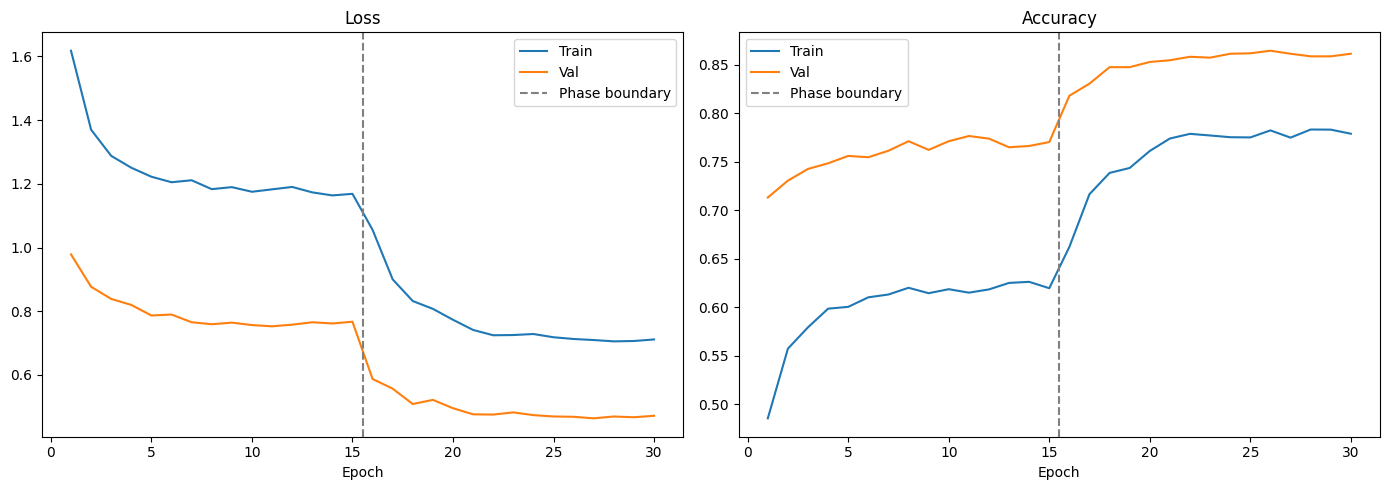

Model saved to gourmetai_best.pth


In [ ]:
def plot_history(h1, h2):
    """
    Visualizes the training and validation history across two different training phases.

    This function concatenates the metrics from the initial classifier training (Phase 1)
    and the subsequent fine-tuning (Phase 2). It generates side-by-side plots for
    Loss and Accuracy, featuring a vertical dashed line to indicate the transition
    between the two phases.

    Args:
        h1 (dict): History dictionary from the first training phase (frozen backbone).
        h2 (dict): History dictionary from the second training phase (fine-tuning).
            Both dictionaries must contain "train_loss", "val_loss", "train_acc",
            and "val_acc" keys.

    Returns:
        None: Displays a Matplotlib figure with two subplots.
    """
    # Concatenate phases
    train_loss = h1["train_loss"] + h2["train_loss"]
    val_loss   = h1["val_loss"]   + h2["val_loss"]
    train_acc  = h1["train_acc"]  + h2["train_acc"]
    val_acc    = h1["val_acc"]    + h2["val_acc"]
    phase_boundary = len(h1["train_loss"])

    epochs = list(range(1, len(train_loss) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tr, vl, title in [
        (ax1, train_loss, val_loss, "Loss"),
        (ax2, train_acc,  val_acc,  "Accuracy"),
    ]:
        ax.plot(epochs, tr, label="Train")
        ax.plot(epochs, vl, label="Val")
        ax.axvline(phase_boundary + 0.5, color="gray", linestyle="--", label="Phase boundary")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_p1, history_p2)

# Save best model checkpoint
torch.save(model.state_dict(), "gourmetai_best.pth")
print("Model saved to gourmetai_best.pth")

The training process was highly successful, as evidenced by the performance charts:<br>

* Fine-Tuning Impact: We observed a marked performance leap during Phase 2. By allowing the last 3 MBConv blocks to adapt to the food dataset, we gained nearly 10% in validation accuracy.<br>

* Model Generalization: The model achieved a final validation accuracy of ~86%. The fact that validation loss remains lower than training loss throughout the process indicates a very robust model that generalizes well to unseen data.<br>

* Optimization Success: The hyperparameter configuration (LR, Weight Decay, and SiLU activation) provided a smooth convergence without volatile oscillations.<br>

Conclusion: The "GourmetAI" model is now ready for deployment. The weights have been saved as gourmetai_best.pth for future use.

## 11. Model Evaluation

To assess the real-world performance of GourmetAI, we evaluate the model on the held-out test set. This step is crucial to ensure the model hasn't just memorized the training data but has actually learned to generalize the features of different dishes.<br>

We generate a comprehensive Classification Report, which provides:<br>

- Precision: The ability of the classifier not to label as positive a sample that is negative.<br>

- Recall: The ability of the classifier to find all the positive samples.<br>

- F1-Score: The harmonic mean of precision and recall, offering a balanced view of performance.<br>

- Support: The number of actual occurrences of each class in the test set.

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

                precision    recall  f1-score   support

  Baked Potato     0.9275    0.8950    0.9109       200
Crispy Chicken     0.8667    0.9100    0.8878       200
         Donut     0.9091    0.9500    0.9291       200
         Fries     0.9204    0.9250    0.9227       200
       Hot Dog     0.7554    0.8800    0.8129       200
      Sandwich     0.8842    0.8400    0.8615       200
          Taco     0.7807    0.7300    0.7545       200
       Taquito     0.8763    0.8150    0.8446       200
     apple_pie     0.8216    0.7600    0.7896       200
    cheesecake     0.8469    0.8850    0.8655       200
 chicken_curry     0.8517    0.8900    0.8704       200
     ice_cream     0.8140    0.8750    0.8434       200
      omelette     0.8936    0.8400    0.8660       200
         sushi     0.9514    0.8800    0.9143       200

      accuracy                         0.8625      2800
     macro avg     0.8642    0.8625    0.8624      2800
  weighted avg     0.8642    0.8625    0.8624 

The classification report confirms that GourmetAI is a robust classifier.<br>

* Reliability: With an F1-score of 0.86, the model is reliable for real-world food recognition.<br>

* Effectiveness of Augmentation: The high scores for categories like Baked Potato and Crispy Chicken prove that the aggressive geometric augmentations used during training helped the model handle various angles and zooms effectively.<br>

* Area for Improvement: Future work could focus on collecting more diverse samples for Tacos and Apple Pies to resolve the slight confusion observed in those categories.

To better understand the specific errors made by our model, we visualize the Confusion Matrix. While the classification report provides summary metrics, the matrix allows us to pinpoint exactly which food categories are being confused with one another.<br>

Why two matrices?<br>
- Count Matrix (Left): Shows the raw number of correct and incorrect predictions, providing a sense of the total volume of samples.<br>

- Normalized Matrix (Right): Expresses the performance in percentages (0.0 to 1.0). This is particularly useful for identifying the "percentage of error" between classes regardless of the total count.<br>

We look for a strong diagonal line, which represents correct predictions where the "True Label" matches the "Predicted Label." Off-diagonal values represent the specific visual similarities that lead the model astray.

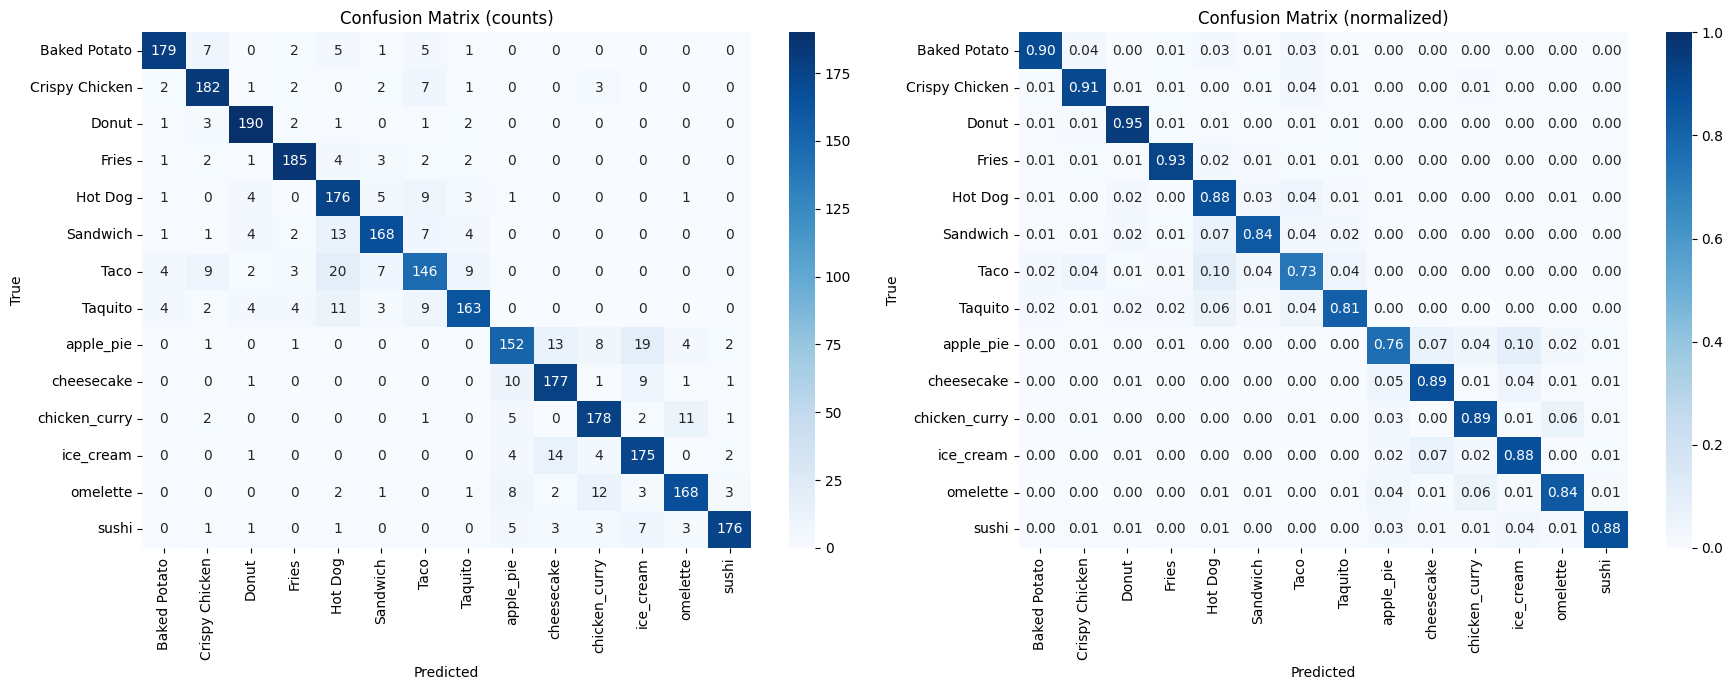

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

# Normalize confusion matrix for better readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt="d", ax=axes[0],
            xticklabels=classes, yticklabels=classes, cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=axes[1],
            xticklabels=classes, yticklabels=classes, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

The Confusion Matrix reveals a highly capable model with specific areas for refinement:<br>

- Success of Augmentation: The robust recognition of Baked Potato and Sushi validates our use of aggressive spatial transforms.<br>

- Semantic Overlap: Most errors occur between visually similar items (e.g., Taco vs Hot Dog). This is a known challenge in food recognition where ingredients often overlap.<br>

- Future Improvements: To further improve accuracy, we could implement Oversampling for the Taco class or add more specific augmentations that emphasize edge detection to better distinguish between the crust of a pie and the texture of an omelette.<br>

## 12. Inference Demo

In [ ]:
def predict_image(image_path: str, top_k: int = 3):
    """
    Performs inference on a single image file and visualizes the results.

    The function loads an image, applies the necessary preprocessing transforms,
    and passes it through the model to obtain class probabilities. It then
    prints the top-K predictions and displays the image with the most likely
    label and its confidence score.

    Args:
        image_path (str): The local path to the image file to be classified.
        top_k (int): The number of top candidate classes to display in the
            console output. Defaults to 3.

    Returns:
        None: The function prints the results to the console and renders
            a Matplotlib figure.
    """
    from PIL import Image
    img = Image.open(image_path).convert("RGB")
    tensor = test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    top_probs, top_idxs = probs.topk(top_k)

    print(f"\nPredictions for: {image_path}")
    for prob, idx in zip(top_probs, top_idxs):
        print(f"  {classes[idx.item()]:25s} {prob.item()*100:.1f}%")

    # Display image with top prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"{classes[top_idxs[0].item()]} ({top_probs[0].item()*100:.1f}%)")
    plt.axis("off")
    plt.show()

# Example usage:
# predict_image("path/to/your/food.jpg")

The ultimate test for any Computer Vision model is its ability to classify images it has never seen before—potentially from completely different sources than our dataset.<br>

Our Inference Pipeline:<br>
- Image Preprocessing: We load the image using PIL and apply the exact same normalization and resizing used during the validation phase to ensure consistency.<br>

- Softmax Activation: Since the model outputs raw "logits," we apply the Softmax function to convert these values into human-readable probabilities (0-100%).<br>

- Top-K Analysis: Instead of just looking at the best guess, we inspect the top 3 candidates. This is particularly useful for food recognition, where a dish might share ingredients with multiple categories.<br>

- Visual Verification: We display the image alongside its prediction to intuitively verify the model's "reasoning."